In [52]:
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

data=pd.read_csv("/kaggle/input/datasets/hashirali12123/exotrain/exoTrain.csv")

In [53]:
data.head()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,2,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,2,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,2,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,2,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54


In [54]:
data.describe()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
count,5087.000000,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,...,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5087.000000,5087.000000,5087.000000,5087.000000
mean,1.007273,1.445054e+02,1.285778e+02,1.471348e+02,1.561512e+02,1.561477e+02,1.469646e+02,1.168380e+02,1.144983e+02,1.228639e+02,...,3.485578e+02,4.956476e+02,6.711211e+02,7.468790e+02,6.937372e+02,6.553031e+02,-494.784966,-544.594264,-440.239100,-300.536399
std,0.084982,2.150669e+04,2.179717e+04,2.191309e+04,2.223366e+04,2.308448e+04,2.410567e+04,2.414109e+04,2.290691e+04,2.102681e+04,...,2.864786e+04,3.551876e+04,4.349963e+04,4.981375e+04,5.087103e+04,5.339979e+04,17844.469520,17722.339334,16273.406292,14459.795577
min,1.000000,-2.278563e+05,-3.154408e+05,-2.840018e+05,-2.340069e+05,-4.231956e+05,-5.975521e+05,-6.724046e+05,-5.790136e+05,-3.973882e+05,...,-3.240480e+05,-3.045540e+05,-2.933140e+05,-2.838420e+05,-3.288214e+05,-5.028894e+05,-775322.000000,-732006.000000,-700992.000000,-643170.000000
25%,1.000000,-4.234000e+01,-3.952000e+01,-3.850500e+01,-3.505000e+01,-3.195500e+01,-3.338000e+01,-2.813000e+01,-2.784000e+01,-2.683500e+01,...,-1.760000e+01,-1.948500e+01,-1.757000e+01,-2.076000e+01,-2.226000e+01,-2.440500e+01,-26.760000,-24.065000,-21.135000,-19.820000
50%,1.000000,-7.100000e-01,-8.900000e-01,-7.400000e-01,-4.000000e-01,-6.100000e-01,-1.030000e+00,-8.700000e-01,-6.600000e-01,-5.600000e-01,...,2.600000e+00,2.680000e+00,3.050000e+00,3.590000e+00,3.230000e+00,3.500000e+00,-0.680000,0.360000,0.900000,1.430000
75%,1.000000,4.825500e+01,4.428500e+01,4.232500e+01,3.976500e+01,3.975000e+01,3.514000e+01,3.406000e+01,3.170000e+01,3.045500e+01,...,2.211000e+01,2.235000e+01,2.639500e+01,2.909000e+01,2.780000e+01,3.085500e+01,18.175000,18.770000,19.465000,20.280000
max,2.000000,1.439240e+06,1.453319e+06,1.468429e+06,1.495750e+06,1.510937e+06,1.508152e+06,1.465743e+06,1.416827e+06,1.342888e+06,...,1.779338e+06,2.379227e+06,2.992070e+06,3.434973e+06,3.481220e+06,3.616292e+06,288607.500000,215972.000000,207590.000000,211302.000000


In [55]:
check_missing=data.isnull().sum()
print(check_missing[check_missing>0])


Series([], dtype: int64)


In [56]:
scaler=StandardScaler()
X=data.drop('LABEL',axis=1)

y=data['LABEL']
y=y-1

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [57]:
from scipy.ndimage import gaussian_filter1d
import numpy as np

# 1. Apply Gaussian Smoothing to reduce deep space static/noise (sigma=3 is a great baseline)
# gaussian_filter1d takes the Pandas DataFrame and returns a smoothed numpy array
X_train_smoothed = gaussian_filter1d(X_train, sigma=3, axis=1)
X_test_smoothed = gaussian_filter1d(X_test, sigma=3, axis=1)

# 2. Calculate mean and std for each star individually (axis=1)
train_mean = X_train_smoothed.mean(axis=1).reshape(-1, 1)
train_std = X_train_smoothed.std(axis=1).reshape(-1, 1)
# Adding 1e-8 prevents division by zero in case of completely flat light curves
X_train_scaled = (X_train_smoothed - train_mean) / (train_std + 1e-8)

test_mean = X_test_smoothed.mean(axis=1).reshape(-1, 1)
test_std = X_test_smoothed.std(axis=1).reshape(-1, 1)
X_test_scaled = (X_test_smoothed - test_mean) / (test_std + 1e-8)

# 3. Reshape scaled arrays for LSTM 3D format: (samples, timesteps, features)
X_train_reshaped = np.expand_dims(X_train_scaled, axis=2)
X_test_reshaped = np.expand_dims(X_test_scaled, axis=2)


In [ ]:
import numpy as np
import tensorflow as tf
from imblearn.over_sampling import SMOTE

# --- BEST PRACTICE: Convert Pandas Series to NumPy array to prevent index mismatch ---
y_train_arr = np.asarray(y_train)

# --- 1. DATA ROTATION AUGMENTATION ---
minority_idx = np.where(y_train_arr == 1)[0]
X_minority = X_train_scaled[minority_idx]

X_rotated = []
y_rotated = []
timesteps = X_train_scaled.shape[1]

# EDGE CASE PROOF: Ensure there is minority data to augment before starting
if len(X_minority) > 0:
    # Generate 3 augmented (shifted) light curves for each real exoplanet
    for _ in range(3):
        for sample in X_minority:
            shift_amount = np.random.randint(1, timesteps)
            X_rotated.append(np.roll(sample, shift_amount))
            y_rotated.append(1)

# EDGE CASE PROOF: Prevent np.vstack crash if rotation list is empty
if len(X_rotated) > 0:
    X_train_aug = np.vstack([X_train_scaled, np.array(X_rotated)])
    y_train_aug = np.concatenate([y_train_arr, np.array(y_rotated)])
else:
    X_train_aug = X_train_scaled
    y_train_aug = y_train_arr

# --- 2. SMOTE OVERSAMPLING ---
# EDGE CASE PROOF: k_neighbors must strictly be smaller than the number of minority samples
k_neighbors = min(5, len(y_train_aug[y_train_aug == 1]) - 1)
smote = SMOTE(random_state=42, k_neighbors=k_neighbors)

X_train_smote, y_train_smote = smote.fit_resample(X_train_aug, y_train_aug)

# --- 3. FINAL RESHAPING FOR LSTM ---
X_train_reshaped = np.expand_dims(X_train_smote, axis=2)
y_train_final = y_train_smote  

print(f"Original exoplanet count in training: {sum(y_train_arr == 1)}")
print(f"Final training distribution [Class 0, Class 1] after Rotation + SMOTE: {np.bincount(y_train_final)}")
print(f"Shape of X_train_reshaped ready for LSTM: {X_train_reshaped.shape}")

# --- 4. FOCAL LOSS INITIALIZATION ---
# Add this built-in binary focal loss function when you compile your model later
focal_loss = tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0, from_logits=False)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization

def build_gru_model(input_shape):
    model = Sequential([
        # First GRU layer reading the light curves
        GRU(64, return_sequences=True, input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.3),
        
        # Second GRU layer condensing the sequence logic
        GRU(32, return_sequences=False),
        BatchNormalization(),
        Dropout(0.3),
        
        # Output layer for binary classification (0 = No Exoplanet, 1 = Exoplanet)
        Dense(1, activation='sigmoid')
    ])
    return model

# Build the model dynamically to perfectly match the shape of your augmented data
# X_train_reshaped.shape[1:] gives (timesteps, 1)
gru_model = build_gru_model(input_shape=X_train_reshaped.shape[1:])

# Compile using the Focal Loss we created earlier, plus the AUC metric!
gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=focal_loss,
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Display the architecture before training
gru_model.summary()

# --- TRAINING EXECUTION ---
# When you are ready to train, simply uncomment the following block:

print("Starting GRU Model Training...")

gru_history = gru_model.fit(
    X_train_reshaped, 
    y_train_final,
    validation_data=(X_test_reshaped, y_test),
    epochs=15,
    batch_size=64,
    # Uncomment the line below if you generated class_weights
    # class_weight=class_weights 
)



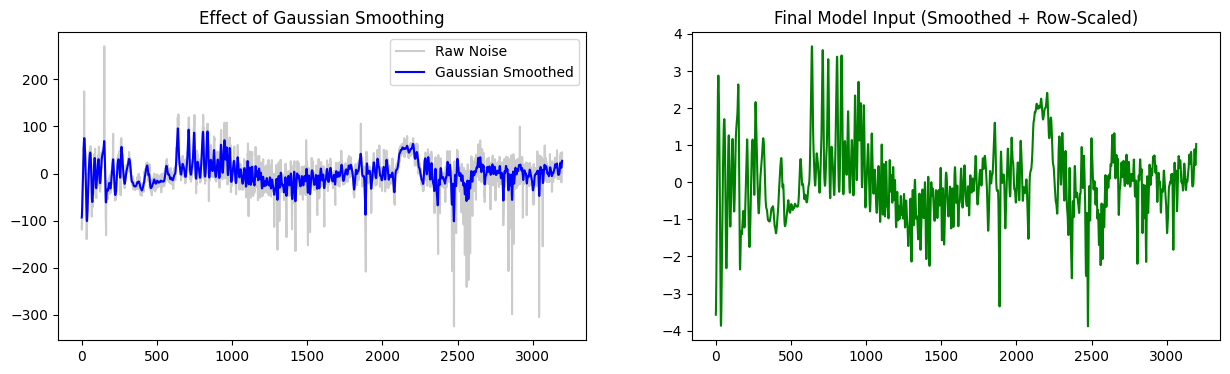

In [58]:
import matplotlib.pyplot as plt

# Find the first positive exoplanet in the shuffled training set
exoplanet_idx = np.where(y_train == 1)[0][0]

plt.figure(figsize=(15, 4))
plt.subplot(1, 2, 1)
plt.plot(X_train.iloc[exoplanet_idx].values, label="Raw Noise", alpha=0.4, color='gray')
plt.plot(X_train_smoothed[exoplanet_idx], label="Gaussian Smoothed", color='blue')
plt.title('Effect of Gaussian Smoothing')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(X_train_scaled[exoplanet_idx], color='green')
plt.title('Final Model Input (Smoothed + Row-Scaled)')
plt.show()


LABEL
0    5050
1      37
Name: count, dtype: int64


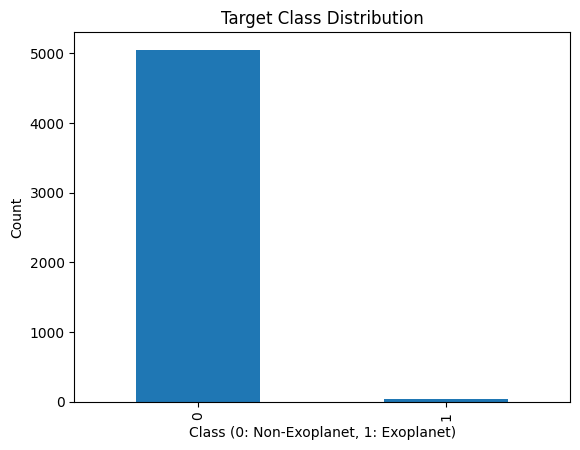

In [59]:
import matplotlib.pyplot as plt

print(y.value_counts())

y.value_counts().plot(kind="bar")
plt.title('Target Class Distribution')
plt.xlabel('Class (0: Non-Exoplanet, 1: Exoplanet)')
plt.ylabel('Count')
plt.show()


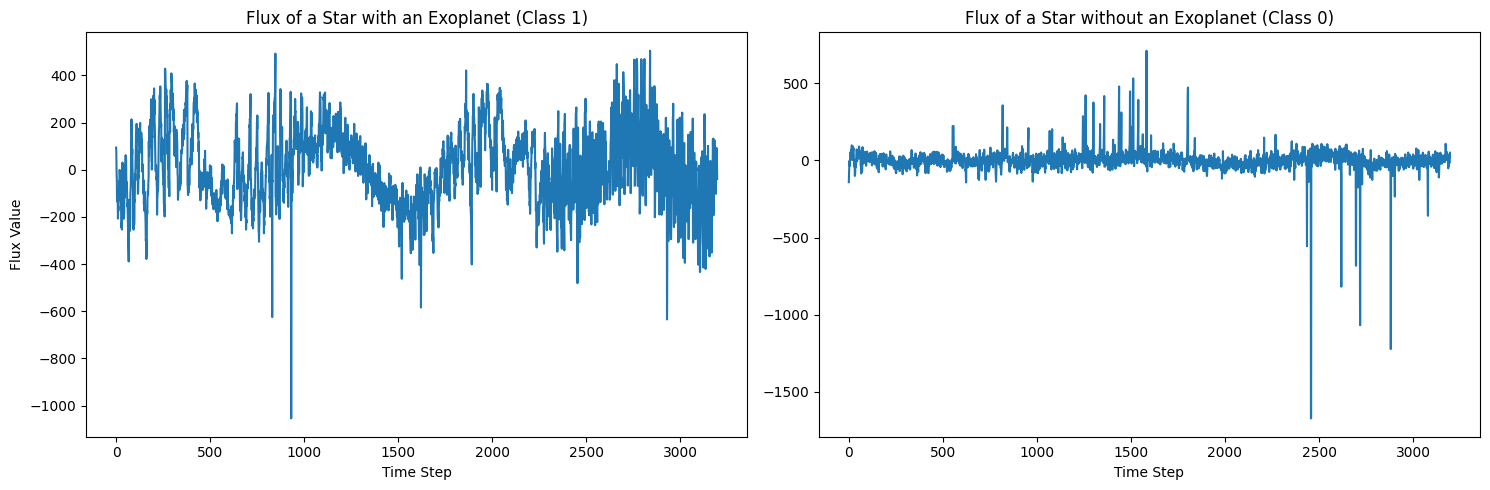

In [60]:
plt.figure(figsize=(15, 5))

# Plot one exoplanet (assuming LABEL 1 is exoplanet)
plt.subplot(1, 2, 1)
plt.plot(X[y == 1].iloc[0].values)
plt.title('Flux of a Star with an Exoplanet (Class 1)')
plt.xlabel('Time Step')
plt.ylabel('Flux Value')

# Plot one non-exoplanet
plt.subplot(1, 2, 2)
plt.plot(X[y == 0].iloc[0].values)
plt.title('Flux of a Star without an Exoplanet (Class 0)')
plt.xlabel('Time Step')

plt.tight_layout()
plt.show()


In [61]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# y_train should be 1D array of 0s and 1s
classes = np.unique(y_train)  # [0, 1]
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(0.5037137905422134), np.int64(1): np.float64(67.81666666666666)}


In [62]:
from tensorflow.keras.callbacks import Callback
from sklearn.metrics import precision_score, recall_score, f1_score
class PrintAfterEpoch(Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        
        # Standard training and validation metrics
        loss = logs.get('loss', 0)
        acc = logs.get('accuracy', 0)
        val_loss = logs.get('val_loss', 0)
        val_acc = logs.get('val_accuracy', 0)
        
        # Compute F1, precision, recall on validation set
        if self.validation_data is not None:
            X_val, y_val = self.validation_data
            y_pred_prob = self.model.predict(X_val, verbose=0)
            y_pred = (y_pred_prob > 0.5).astype(int)
            
            precision = precision_score(y_val, y_pred, zero_division=0)
            recall = recall_score(y_val, y_pred, zero_division=0)
            f1 = f1_score(y_val, y_pred, zero_division=0)
        else:
            precision = recall = f1 = 0
        
        print(f"Epoch {epoch+1}: loss={loss:.4f}, accuracy={acc:.4f}, val_loss={val_loss:.4f}, val_accuracy={val_acc:.4f}, val_precision={precision:.4f}, val_recall={recall:.4f}, val_f1={f1:.4f}")

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, roc_auc_score
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64,return_sequences=True,input_shape=(X_train_reshaped.shape[1],X_train_reshaped.shape[2])),
    LSTM(64,return_sequences=True,dropout=0.4),
    LSTM(32,return_sequences=True,dropout=0.4),
    LSTM(16),
    Dense(1,activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='focal_loss',
    metrics=['accuracy']
)
callback=PrintAfterEpoch()
callback.validation_data = (X_test_reshaped, y_test)
call_back_list=[early_stop,callback]


history = model.fit(
    X_train_reshaped,  # (samples, timesteps, 1)
    y_train_final,           # binary labels: 0 or 1
    epochs=20,         # you can start with 20
    batch_size=32,
    validation_data=(X_test_reshaped, y_test), # optional, for monitoring
    callbacks=[call_back_list],
    class_weight=class_weight_dict
    )

loss, accuracy = model.evaluate(X_test_reshaped, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

y_pred_prob = model.predict(X_test_reshaped)  # probabilities (0-1)
y_pred = (y_pred_prob > 0.5).astype(int)      # convert to 0 or 1

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.3058 - loss: 0.8234Epoch 1: loss=0.7141, accuracy=0.2657, val_loss=0.7026, val_accuracy=0.2387, val_precision=0.0090, val_recall=1.0000, val_f1=0.0177
128/128 ━━━━━━━━━━━━━━━━━━━━ 69s 513ms/step - accuracy: 0.3055 - loss: 0.8226 - val_accuracy: 0.2387 - val_loss: 0.7026
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.5952 - loss: 0.6355Epoch 2: loss=0.6973, accuracy=0.6326, val_loss=1.2753, val_accuracy=0.0806, val_precision=0.0074, val_recall=1.0000, val_f1=0.0147
128/128 ━━━━━━━━━━━━━━━━━━━━ 64s 503ms/step - accuracy: 0.5954 - loss: 0.6360 - val_accuracy: 0.0806 - val_loss: 1.2753
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.3779 - loss: 0.7384Epoch 3: loss=0.7215, accuracy=0.4448, val_loss=0.5512, val_accuracy=0.9931, val_precision=0.0000, val_recall=0.0000, val_f1=0.0000
128/128 ━━━━━━━━━━━━━━━━━━━━ 64s 502ms/step - accuracy: 0.3785 - loss: 0.7383 - val_accuracy: 0.9931 - 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


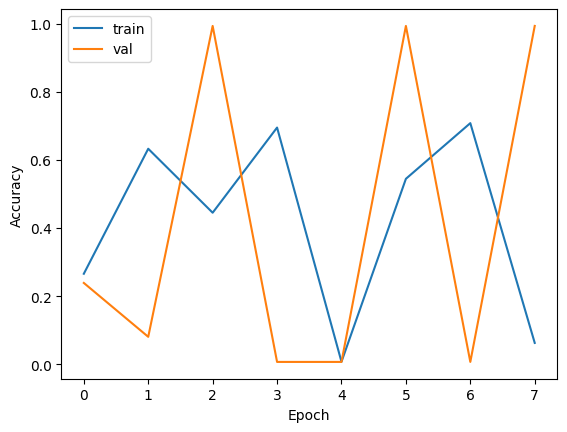

In [64]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, roc_auc_score, roc_curve, f1_score

def evaluate_model(model, X_test, y_true, model_name="Model"):
    """
    Predicts probabilities, extracts SciKit metrics, 
    verifies gradient health, and packages them up for clean comparison.
    """
    # 1. Generate Probability Predictions
    y_pred_probs = model.predict(X_test, verbose=0).ravel()
    
    # EDGE CASE PROOF: Check for 'Exploding Gradients' (NaN collapse)
    if np.isnan(y_pred_probs).any():
        print(f"WARNING: '{model_name}' experienced Exploding Gradients and output NaNs. Please check learning rate.")
        return None, None
    
    # 2. Convert to binary labels (Standard Threshold = 0.5)
    y_pred_labels = (y_pred_probs > 0.5).astype(int)
    
    # 3. Calculate Core Metrics safely (zero_division=0 prevents warning crashes)
    precision = precision_score(y_true, y_pred_labels, zero_division=0)
    recall = recall_score(y_true, y_pred_labels, zero_division=0)
    f1 = f1_score(y_true, y_pred_labels, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_pred_probs)
    
    # 4. Generate ROC Curve coordinates for plotting
    fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
    
    # Package into a dictionary for Pandas
    metrics = {
        "Model": model_name,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }
    
    return metrics, (fpr, tpr, roc_auc)


# --- EVALUATION EXECUTION ---

# 1. Gather Metrics for both models 
lstm_eval = evaluate_model(model, X_test_reshaped, y_test, "LSTM Model")
gru_eval = evaluate_model(gru_model, X_test_reshaped, y_test, "GRU Model")

# Only proceed with printing and plotting if both models are healthy
if lstm_eval[0] is not None and gru_eval[0] is not None:
    lstm_metrics, lstm_roc = lstm_eval
    gru_metrics, gru_roc = gru_eval

    # 2. Display the Comparison DataFrame
    print("\n--- PERFORMANCE METRICS COMPARISON ---")
    results_df = pd.DataFrame([lstm_metrics, gru_metrics])
    display(results_df.round(4))

    # 3. Plot ROC Curve Overlay
    plt.figure(figsize=(10, 6))

    # Plot LSTM Curve
    plt.plot(lstm_roc[0], lstm_roc[1], label=f'LSTM (AUC = {lstm_roc[2]:.4f})', color='blue', linewidth=2.5)
    
    # Plot GRU Curve
    plt.plot(gru_roc[0], gru_roc[1], label=f'GRU (AUC = {gru_roc[2]:.4f})', color='red', linewidth=2.5)

    # Plot standard random guess baseline
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing (AUC = 0.5)')

    # Formatting the visual
    plt.title('ROC Curve Comparison: LSTM vs GRU', fontsize=14, pad=15)
    plt.xlabel('False Positive Rate\n(Normal Stars accidently predicted as Exoplanets)', fontsize=11)
    plt.ylabel('True Positive Rate\n(Exoplanets correctly caught)', fontsize=11)
    plt.legend(loc='lower right', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.show()
